# 3 Data analysis

## Setup

### Load Libraries

In [3]:
library(tidyverse)
library(plotrix)
library(RColorBrewer)
library(patchwork)
library(tools)
library(readxl)
library(scales)


options(warn = -1)

### Set working directory

In [ ]:
wd <- "/path/to/03_image_analysis/06_growth_at_28C"
setwd(wd)

### Load and tidy metadata

In [89]:
# Load metadata Excel sheet
md_path <- file.path(wd, "02_data", "tables", "assay_layout.xlsx")
md <- read_excel(md_path)

# Convert to tidy format
tidy_md <- md %>%
  gather(key = "column", value = "value", -plate, -row, -type) %>%
  pivot_wider(names_from = type, values_from = value) %>%
  mutate(column = as.numeric(column)) %>%
  rename(col = column) %>%
  arrange(plate, row, col) %>%
  select(plate, col, row, strain, treatment, group)


### Load and prepare raw cell data

In [88]:
# Load segmentation result table
path <- file.path(wd, "02_data", "tables", "cell_analysis_results.csv")
data_raw <- read.csv(path, header = TRUE, check.names = TRUE)

# Extract metadata from filenames
data <- data_raw %>%
  mutate(filename = basename(filename)) %>%
  separate(filename, into = c("plate", "row", "col", "region"), sep = "_", remove = FALSE) %>%
  mutate(plate = str_replace(plate, "p", "")) %>%
  select(filename, plate, row, col, region, cell_label, area) %>%
  arrange(filename)

## Analysis

Summarize data from regions to strains

In [ ]:
# define regions R1–R9
region_levels <- paste0("R", 1:9)

# keep wells with valid group metadata
tidy_md_f <- tidy_md %>%
  mutate(col = as.numeric(col), plate = as.numeric(plate)) %>%
  filter(!is.na(group))

# scaffold = all wells × all regions
scaffold <- tidy_md_f %>%
  distinct(plate, row, col) %>%
  crossing(region = factor(region_levels, levels = region_levels))

# per-region metrics
summary_by_region <- data %>%
  mutate(col = as.numeric(col), plate = as.numeric(plate)) %>%
  group_by(plate, row, col, region) %>%
  summarise(
    n.region = n(),
    area.region.mean = mean(area, na.rm = TRUE),
    area.region.max  = max(area, na.rm = TRUE),
    .groups = "drop"
  )

# join scaffold with summaries (fill n=0, keep NA areas)
data_summary_regions <- scaffold %>%
  left_join(summary_by_region, by = c("plate","row","col","region")) %>%
  mutate(n.region = tidyr::replace_na(n.region, 0)) %>%
  left_join(tidy_md_f, by = c("plate","row","col"))

# identify metadata vs numeric columns
md_cols_keep <- setdiff(names(tidy_md), c("plate","row","col","region"))
numeric_cols <- data_summary_regions %>%
  select(-plate, -row, -col, -region) %>%
  select(where(is.numeric)) %>%
  names()

# summarise to well-level
data_summary_wells_md <- data_summary_regions %>%
  group_by(plate, row, col) %>%
  summarise(
    across(all_of(md_cols_keep), ~ dplyr::first(.x), .names = "{.col}"),
    n = n(),
    across(
      all_of(numeric_cols),
      list(
        mean = ~ mean(.x, na.rm = TRUE),
        se   = ~ sd(.x, na.rm = TRUE) / sqrt(n()),
        max  = ~ max(.x, na.rm = TRUE)
      ),
      .names = "{.col}.{.fn}"
    ),
    .groups = "drop"
  )

# final summary for plotting (subset + aggregation)
data_summary <- data_summary_wells_md %>%
  mutate(col = as.numeric(col), plate = as.numeric(plate)) %>%
  select(row, col, n.region.mean, treatment, strain, group) %>%
  group_by(treatment, strain, group) %>%
  slice_head(n = 3) %>%
  rename(cell_count = n.region.mean) %>%
  summarise(
    n = n(),
    across(
      .cols = c(cell_count),
      .fns = list(
        mean = ~ mean(.x, na.rm = TRUE),
        sd   = ~ sd(.x, na.rm = TRUE),
        max  = ~ max(.x, na.rm = TRUE)
      ),
      .names = "{.col}.{.fn}"
    ),
    .groups = "drop"
  )

## Vizualization

#### Prepare for plotting

Define color schemes and factor levels

In [ ]:
# set base colors for plotting
wt_colors     <- brewer.pal(n = 9, name = "Greens")
disfp_colors  <- brewer.pal(n = 9, name = "Purples")
rescue_colors <- brewer.pal(n = 9, name = "Blues")

# index for consistent tone across strains
color_nr <- 6

# map strains to selected colors
strain_colors <- c(
  "wt"    = wt_colors[color_nr],
  "disfp" = disfp_colors[color_nr],
  "re"    = rescue_colors[color_nr]
)

# rename strains for figure labels
strain_rename <- c(
  "disfp" = bquote(italic(disfp)^"–" ~ "mutant"),
  "wt"    = bquote("Ax2 wildtype"),
  "re"    = bquote(italic(disfp)^"–" ~ "rescue")
)


 Define scaling parameters

In [127]:
# Image dimensions and physical scale (µm)
pixels_x <- 2049
pixels_y <- 2049
physical_length_in_uM_x <- 338.98
physical_length_in_uM_y <- 338.98

# Calculate scale factors
scale_factor_x <- physical_length_in_uM_x / pixels_x
scale_factor_y <- physical_length_in_uM_y / pixels_y
scale_factor   <- (scale_factor_x + scale_factor_y) / 2  # averaged

# Field of view area in mm²
FOV_area_mm2 <- (physical_length_in_uM_x * physical_length_in_uM_y) / 1e6

 Set factor levels

In [126]:
strain_levels    <- c("wt", "disfp", "re")

####  Bar plot of growth at 28 °C

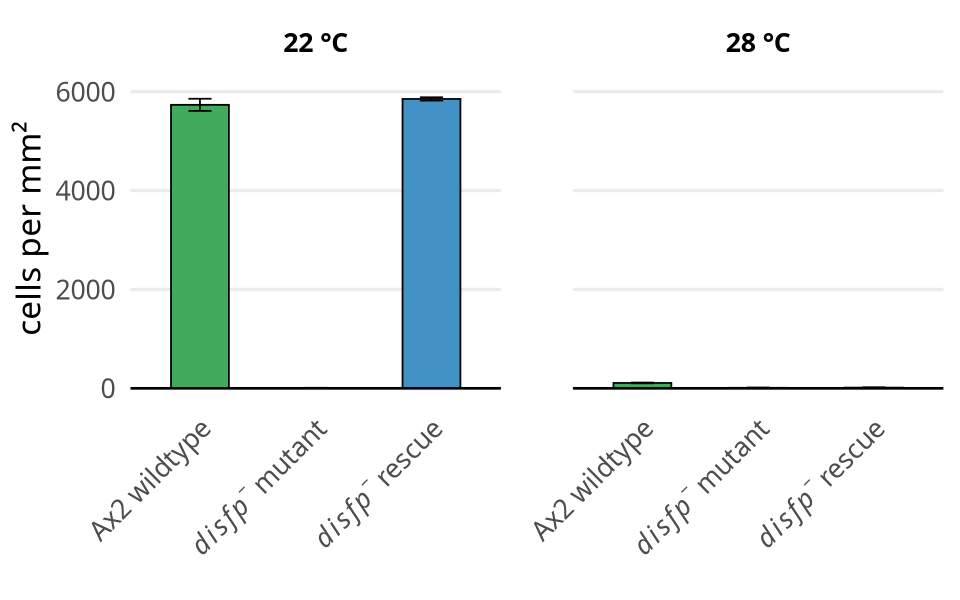

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 5)

data_summary %>%
  filter(treatment == "temp22vs28") %>%
  mutate(strain = factor(strain, levels = strain_levels)) %>%
  ggplot(aes(x = strain, y = cell_count.mean / FOV_area_mm2, fill = strain)) +
  geom_col(
    position = position_dodge(width = 0.6),
    width = 0.5,
    color = "black"
  ) +
  geom_errorbar(
    aes(
      ymin = (cell_count.mean - cell_count.sd) / FOV_area_mm2,
      ymax = (cell_count.mean + cell_count.sd) / FOV_area_mm2
    ),
    position = position_dodge(width = 0.6),
    width = 0.2
  ) +
  labs(y = "cells per mm²", x = "") +
  scale_fill_manual(values = strain_colors, labels = strain_rename) +
  scale_x_discrete(labels = strain_rename) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  theme_minimal(base_size = 20) +
  facet_wrap(
    ~ group,
    labeller = labeller(group = c(control = "22 °C", treatment = "28 °C"))
  ) +
  guides(fill = guide_legend(direction = "horizontal")) +
  theme(
    panel.border        = element_blank(),
    panel.spacing       = unit(3, "lines"),
    panel.grid.major.x  = element_blank(),
    panel.grid.minor.x  = element_blank(),
    panel.grid.minor.y  = element_blank(),
    axis.line.x         = element_line(color = "black", size = 0.75),
    axis.ticks.x        = element_blank(),
    axis.ticks.y        = element_blank(),
    strip.text.x        = element_text(color = "black", face = "bold"),
    axis.text.x         = element_text(angle = 45, hjust = 1, vjust = 0.9),
    strip.background    = element_rect(colour = "white", fill = "white"),
    legend.position     = "none",
    legend.justification = c("left", "top")
  )
